<a href="https://colab.research.google.com/github/srikanth713/Restaurant_model/blob/main/restaurantprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor

print("All necessary libraries imported.")

All necessary libraries imported.


### 1. Load the Dataset

In [ ]:
df = pd.read_csv('Dataset .csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2. Initial Data Inspection

In [ ]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  

In [ ]:
print("Column names:")
print(df.columns)

Column names:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [ ]:
print("Sum of null values per column:")
print(df.isna().sum())

Sum of null values per column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [ ]:
print("Duplicated rows:")
print(df.duplicated().sum())

Duplicated rows:
0


### 3. Data Preprocessing and Encoding

In [ ]:
# Handle null values in 'Cuisines'
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Initialize LabelEncoder
le = LabelEncoder()

# Identify categorical columns for Label Encoding
categorical_cols_to_encode = [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Currency',
    'Rating color',
    'Rating text',
    'City'
]

# Apply Label Encoding
for col in categorical_cols_to_encode:
    df[col] = le.fit_transform(df[col])

print("Null values in 'Cuisines' filled and selected categorical columns label encoded.")

Null values in 'Cuisines' filled and selected categorical columns label encoded.


### 4. Define Features (X) and Target (y)

In [ ]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]
print("Features (X) and target (y) defined.")

Features (X) and target (y) defined.


### 5. Drop Non-Numeric Columns from Features

In [ ]:
# Identify and drop non-numeric columns that are not suitable for direct model input
columns_to_drop_from_X = [
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Cuisines', # Now filled, but still categorical and potentially high cardinality
    'Switch to order menu'
]

# Drop these columns from X
X_processed = X.drop(columns=columns_to_drop_from_X, errors='ignore')
print("Non-numeric columns dropped from features.")

Non-numeric columns dropped from features.


### 6. Split Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)
print("Data split into training and testing sets.")

Data split into training and testing sets.


### 7. Initialize and Train Decision Tree Regressor

In [ ]:
DT = DecisionTreeRegressor()
DT.fit(X_train, y_train)
print("Decision Tree Regressor model has been rebuilt and trained successfully!")

Decision Tree Regressor model has been rebuilt and trained successfully!


### 8. Evaluate Model Performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = DT.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

print("\nModel performance evaluation complete.")

Mean Absolute Error (MAE): 0.1424
Mean Squared Error (MSE): 0.0513
R-squared (R2) Score: 0.9775

Model performance evaluation complete.


### 9. Visualize Predictions vs. Actuals

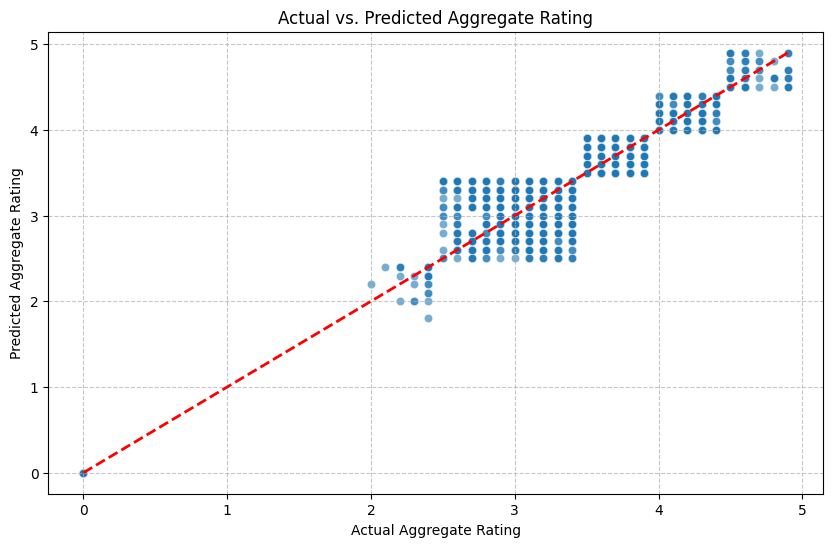

Visualization of actual vs. predicted ratings generated.


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Aggregate Rating")
plt.ylabel("Predicted Aggregate Rating")
plt.title("Actual vs. Predicted Aggregate Rating")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Visualization of actual vs. predicted ratings generated.")

### 10. Save the Trained Model

In [ ]:
import joblib

# Define a filename for the model
model_filename = 'decision_tree_regressor_model.joblib'

# Save the trained model to the file
joblib.dump(DT, model_filename)

print(f"Model successfully saved to '{model_filename}'")

Model successfully saved to 'decision_tree_regressor_model.joblib'


### 11. Load and Test the Saved Model (Optional Demonstration)

In [ ]:
# Load the model back from the file
loaded_model = joblib.load(model_filename)

# Make predictions using the loaded model
loaded_model_y_pred = loaded_model.predict(X_test)

# Compare predictions to verify
comparison_result = (y_pred == loaded_model_y_pred).all()
print(f"Predictions from original and loaded model are identical: {comparison_result}")

print("Model loaded and tested successfully.")

Predictions from original and loaded model are identical: True
Model loaded and tested successfully.


Now you have a saved model file (`decision_tree_regressor_model.joblib`) that you can use for future predictions or integrate into other applications. This file is now available in your Colab environment's file system.